# Comparison of Bagging and Boosting
### Does the variance-reduction of parallel ensembles offer better generalization on noisy sensor data compared to the bias-reduction of sequential ensembles?

The goal of this section is to build, evaluate and compare different ensemble models to classify air quality into four categories: Good, Moderate, Poor, and Hazardous. Getting a final model able to predict severe pollution cases with fiability is the main focus of this analysis.

## These are the ensemble techniques we are going to explore: 

| # | Technique | Main desc. | Implementation |
|:---:|:---|:---|:---|
| **1** | **Voting ensemble** | Combines diverse models (LR, RF, SVC). | **Hard** (Majority) vs **Soft** (Average Proba) |
| **2** | **Bagging and Pasting** | Parallel training on data subsets. | **Bagging** (w/ replacement) vs **Pasting** (w/o) |
| **3** | **Boosting** | Sequential training to correct prior errors. | **AdaBoost** & **Gradient Boosting** |
| **4** | **XGBoost** | High-performance Gradient Boosting. | System optimization & Regularization |
| **5** | **Stacking ensemble** | Multi-layer ensemble with a Meta-learner. | Uses a final model to blend predictions |

All models are evaluated using metrics that focus on class imbalances, Accuracy, Macro F1-Score, Weighted F1-Score, and the Matthews Correlation Coefficient (MCC).

With a final performance comparison analysis.

## 0. Initial Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, cohen_kappa_score, classification_report, ConfusionMatrixDisplay, matthews_corrcoef)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.ensemble import ( BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier, StackingClassifier)

import warnings
warnings.filterwarnings("ignore") # To hide warnings whwen we run code 

In [2]:
# This peace of code comes from the EDA of the 00_baselines notebook
data = pd.read_csv("../data/updated_pollution_dataset.csv")

target_col = data.columns[-1]

quality_map = {
    "Good": 3,
    "Moderate": 2,
    "Poor": 1,
    "Hazardous": 0
}

data[target_col] = data[target_col].map(quality_map)
data[target_col] = data[target_col].astype("int8")

In [3]:
# Train test split
X, y = data.drop(columns=data.columns[-1]), data[data.columns[-1]]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [4]:
CLASS_NAMES = ["Hazardous", "Poor", "Moderate", "Good"]

# This function shows 4 metrics for the selected technique
def evaluate(model, X, y_true, name="Technique"):
    y_pred = model.predict(X)

    acc = accuracy_score(y_true, y_pred)                  # Acuraccy
    f1_macro = f1_score(y_true, y_pred, average="macro")    # Macro F1
    f1_weight = f1_score(y_true, y_pred, average="weighted") # Weighted F1
    mcc = matthews_corrcoef(y_true, y_pred)               # Matthews Correlation Coefficient


    print(name, "\n-----------------------------------")  # Technique name
    print(f"  Accuracy    : {acc}")      
    print(f"  Macro F1    : {f1_macro:.4f} ") 
    print(f"  Weighted F1 : {f1_weight:.4f}")   
    print(f"  Matthews CC : {mcc:.4f}\n")      

    return {"Technique": name, "Accuracy": acc, "Macro F1": f1_macro,
            "Weighted F1": f1_weight, "Matthews Correlation Coefficient": mcc}

We will use this evaluate function to compare the models with the same metrics mentioned at the start.

## 1. Voting Ensemble 

First ensemble models using VotingClassifier. We combine three models: Logistic Regression, Support Vector Classifier, and Random Forest. 

Following two strategies:

`Hard Voting:` Predicts the class that receives the majority of votes from the models.

`Soft Voting:` Average of the predicted probability scores from all models and chooses the class with the highest average probability.

In [159]:
# Define models
logistic_model = LogisticRegression(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)
svm_model = SVC(random_state=42, probability=True)

# Hard voting classifier
hard_voting_clf = VotingClassifier(
    estimators=[("logistic", logistic_model),
                ("randomforest", random_forest_model),
                ("svc", svm_model)], voting="hard")

# Train and evaluate
hard_voting_clf.fit(X_train, y_train)

hard_metrics = evaluate(hard_voting_clf, X_test, y_test, "Hard Voting")


Hard Voting 
-----------------------------------
  Accuracy    : 0.8816
  Macro F1    : 0.8173 
  Weighted F1 : 0.8790
  Matthews CC : 0.8294



In [160]:
# Accuracy for each estimator
for name, clf in hard_voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

print("\nPredictions for the first sample:\n",[clf.predict(X_test[:1]) for clf in hard_voting_clf.estimators_])

logistic = 0.7496
randomforest = 0.9544
svc = 0.756

Predictions for the first sample:
 [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]


In [161]:
# Soft voting classifier
soft_voting_clf = VotingClassifier(
    estimators=[("logistic", logistic_model),
                ("randomforest", random_forest_model),
                ("svc", svm_model)], voting="soft")

# Train and evaluate
soft_voting_clf.fit(X_train, y_train)
 
soft_metrics = evaluate(soft_voting_clf, X_test, y_test, "Soft Voting")
print("\n")

# Accuracy for each estimator
for name, clf in soft_voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test))

print("\nPredictions for the first sample:\n",[clf.predict(X_test[:1]) for clf in soft_voting_clf.estimators_])

Soft Voting 
-----------------------------------
  Accuracy    : 0.9256
  Macro F1    : 0.8870 
  Weighted F1 : 0.9246
  Matthews CC : 0.8932



logistic = 0.7496
randomforest = 0.9544
svc = 0.756

Predictions for the first sample:
 [array([0], dtype=int64), array([0], dtype=int64), array([0], dtype=int64)]


The results show that the Soft Voting `(Macro F1 0.887)` performs significantly better than Hard Voting `(Macro F1: 0.817)`. This happens because Soft Voting takes into account the `confidence` of the predictions. Random Forest is the strongest model `(95% accuracy)`, and Soft Voting takes advantage of its confident predictions ingoring the less confident logistic regression or SVC models.

## 2. Bagging and Pasting

The second step is for parallel tree ensembles.

`Bagging:` Trains base models on random subsets of the data with replacement `(bootstrap=True)`.

`Pasting:` Trains base models on random subsets of the data without replacement `(bootstrap=False)`.

Here we will see the `Out of Bag (OOB)` score for the Bagging model, which acts as a free validation set using the samples left out during the bootstrap process.

In [ ]:
bag_clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None,min_samples_leaf=2), n_estimators=300, 
                            max_samples=0.8, max_features=0.8, bootstrap= True, oob_score= True, n_jobs=-1, random_state=42)

past_clf = BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=None,min_samples_leaf=2), n_estimators=300, 
                             max_samples=0.8, max_features=0.8, bootstrap= False, oob_score=False, n_jobs=-1, random_state=42)

bag_clf.fit(X_train, y_train)
past_clf.fit(X_train, y_train)

print("Bagging - Out Of Bag (OOB) Score: ", bag_clf.oob_score_,"\n")

bag_metrics  = evaluate(bag_clf,  X_test, y_test, "Bagging (Replacement)")
past_metrics = evaluate(past_clf, X_test, y_test, "Pasting (No Replacement)")

Bagging - Out Of Bag (OOB) Score:  0.9504 

Bagging (Replacement) 
-----------------------------------
  Accuracy    : 0.9488
  Macro F1    : 0.9240 
  Weighted F1 : 0.9487
  Matthews CC : 0.9265

Pasting (No Replacement) 
-----------------------------------
  Accuracy    : 0.9464
  Macro F1    : 0.9204 
  Weighted F1 : 0.9463
  Matthews CC : 0.9231



In [163]:
# OOB Score per class
oob_proba = bag_clf.oob_decision_function_
oob_pred  = np.argmax(oob_proba, axis=1)

classes = bag_clf.classes_
oob_pred_mapped = classes[oob_pred]

print("OOB Classification Report:")
print(classification_report(y_train, oob_pred_mapped, target_names=["Hazardous","Poor","Moderate","Good"]))

OOB Classification Report:
              precision    recall  f1-score   support

   Hazardous       0.89      0.85      0.87       368
        Poor       0.89      0.88      0.89       771
    Moderate       0.95      0.97      0.96      1119
        Good       1.00      1.00      1.00      1492

    accuracy                           0.95      3750
   macro avg       0.93      0.92      0.93      3750
weighted avg       0.95      0.95      0.95      3750



Bagging and Pasting get `Macro F1 scores over 0.92`, with an `Out of Bag score of 0.95`, we think it's a reliable estimate of model performance. The OOB classification suggests that the model struggles more with the `"Hazardous" class (Recall 0.85)` compared to the `"Good" class (Recall 1.00)`, showing a class imbalance, we will work on this in the imbalance notebook.


## 3. Boosting
This section is about sequential ensembles. Unlike Bagging, each model tries to correct the errors of the previous one.

First, we train an `AdaBoostClassifier` and then optimize its hyperparameters using `GridSearch`. 

Second, a `GradientBoostingClassifier` with early stopping at 10 to preventing overfitting.

### 3a. AdaBoost

`AdaBoost classifier` is implemented using a decision tree with a depth of 3 estimator. After, we will look for the best hyperparameters using GridShearch and see how better can it perform. We especially expect `high improvement in the Macro-F1 score` of the fine tuned model. 

In [164]:
ada_clf = AdaBoostClassifier( estimator=DecisionTreeClassifier(max_depth=3), n_estimators=200, learning_rate=0.5, random_state=42)
ada_clf.fit(X_train, y_train)

ada_metrics = evaluate(ada_clf, X_test, y_test, "AdaBoost")

AdaBoost 
-----------------------------------
  Accuracy    : 0.944
  Macro F1    : 0.9156 
  Weighted F1 : 0.9444
  Matthews CC : 0.9199



In [165]:
# GridSearch to search the best hiperparameters of AdaBoost
parameters = {"n_estimators": [10,30,50, 100,250,300, 400], 
              "learning_rate": [0.01, 0.1, 0.5, 0.75, 1], 
              "estimator__max_depth": [1, 2, 3, 4], 
              "estimator__min_samples_leaf": [1, 2, 5]}

ada_grid_clf = GridSearchCV(ada_clf, parameters, cv=5, verbose=3, n_jobs=-1, scoring="f1_macro")
ada_grid_clf.fit(X_train, y_train)

print(f"Best hyperparameters: {ada_grid_clf.best_params_}\n")
ada_grid_metrics = evaluate(ada_grid_clf.best_estimator_, X_test, y_test, "AdaBoost with GridSearch")

Fitting 5 folds for each of 420 candidates, totalling 2100 fits
Best hyperparameters: {'estimator__max_depth': 4, 'estimator__min_samples_leaf': 2, 'learning_rate': 0.1, 'n_estimators': 250}

AdaBoost with GridSearch 
-----------------------------------
  Accuracy    : 0.948
  Macro F1    : 0.9209 
  Weighted F1 : 0.9482
  Matthews CC : 0.9257



The initial AdaBoost model achieved an `accuracy of 0.944` and `Macro F1 of 0.9156`. After the GridSearch having tested 420 candidates, its tuning improved the `accuracy to 0.948` and `Macro F1-score to 0.9209`, and the Matthews Correlation Coefficient `(MCC) to 0.9257`. 

While the accuracy improvement is not high, the lack of class balance makes it less reliable anyways, so the Macro F1 score confirms that fine tuning the base classifier and the ensemble learning gets better generalization. 

### 3b. Gradient Boosting

We now implement the `GradientBoostingClassifier`, which focuses on fiting following models to the residual errors of previous predictions using a gradient descent approach. We also use early stopping to prevent overfitting, this way `we expect this model to be better than a Gridsearch-boosted AdaBoost.` 

In [166]:
gb_clf = GradientBoostingClassifier(n_estimators=500, learning_rate=0.05, max_depth=3, subsample=0.8, 
                                    min_samples_leaf=2, n_iter_no_change=10, validation_fraction=0.1, random_state=42)
gb_clf.fit(X_train, y_train)

print(f"GradientBoosting - Used Estimators (early stopping at 10): {gb_clf.n_estimators_}\n")
gradientboost_metrics = evaluate(gb_clf, X_test, y_test, "GradientBoosting")

GradientBoosting - Used Estimators (early stopping at 10): 134

GradientBoosting 
-----------------------------------
  Accuracy    : 0.9528
  Macro F1    : 0.9297 
  Weighted F1 : 0.9528
  Matthews CC : 0.9324



As we suggested, and even though we set 500 estimators, after stopping at 134, this model outperforms Adaboost in every metric, getting a `Macro F1 of 0.9297`. Continuing the training would have overfitted the model so we think we did well using early stopping. 

Until now, `the metrics of the models we tested are quite similar`, so if the following ones are even better, it would be great for our analysis.  

## 4. XGBoost

XGBoost is an advanced implementation of Gradient Boosting that includes regularization to prevent overfitting and we are using it with 10 rounds. As its feature sorting and tree build are paralellized, it `runs faster`. We think that this model can perform as good as the rest of out models or better, but `we are not sure that in the case that it has better scores, if it will make a meaningfull improvement.`

In [5]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,          
    colsample_bytree=0.8,  
    eval_metric="mlogloss",
    early_stopping_rounds=10,
    random_state=42
)

xgb_clf.fit(X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False)

print(f"XGBoost - Used Estimators (early stopping at 10): {xgb_clf.best_iteration}\n")
xgb_metrics = evaluate(xgb_clf, X_test, y_test, "XGBoost")

XGBoost - Used Estimators (early stopping at 10): 127

XGBoost 
-----------------------------------
  Accuracy    : 0.956
  Macro F1    : 0.9351 
  Weighted F1 : 0.9563
  Matthews CC : 0.9371



With an `Accuracy of 0.956` and a `Macro F1 of 0.9351`, XGBoost has gotten the highest scores so far, so we place it as our `best model so far`. The training stopped at 127 iterations, and the `MCC of 0.9371` indicates that the model is highly reliable across all four air quality categories.

Now we want to gather some insight from `the classes to which XGBoost gives most importance.` 

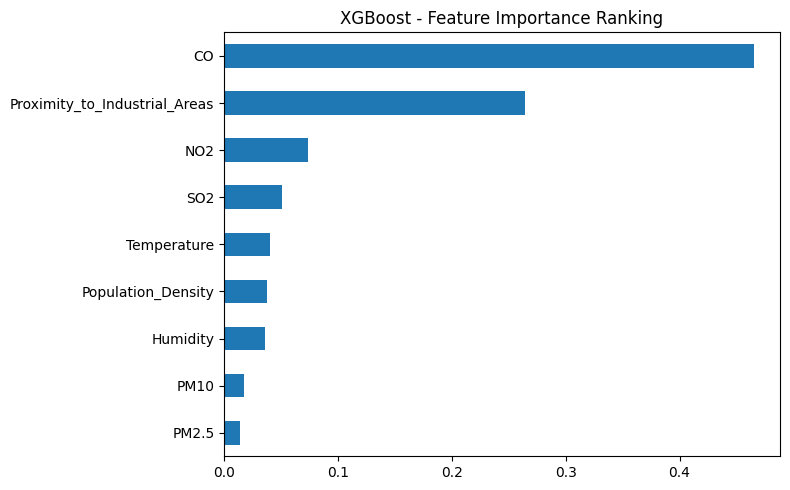

In [9]:
# Feature importance of XGBoost
importances = pd.Series(xgb_clf.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).tail(9).plot(kind="barh", figsize=(8, 5), title="XGBoost - Feature Importance Ranking")
plt.tight_layout()
plt.show()

As the graphic shows, there are `2 classes with a clearly major weight on XGBoost's predictions`. These are `"CO" and "Proximity to Industrial areas"`. Probably suggesting a `high correlation between a hazardous air quality level in places near industrial areas and consequentialy high CO levels`.   

## 5. Stacking Ensemble

The `Stacked generalization` is based on using a trained model in charge of aggregating the models that make predictions. It gets sample predictions of the models to train it, with the `objective of getting a better final prediction than any of the models would do individually.`

In [ ]:
stacking_clf =StackingClassifier(
    estimators=[
    ("logistic", logistic_model),
    ("randomforest", random_forest_model),
    ("svc", svm_model)],
    final_estimator=RandomForestClassifier(random_state=42), cv=5, n_jobs=-1)

stacking_clf.fit(X_train, y_train)
stack_metrics = evaluate(stacking_clf, X_test, y_test, "Stacking")

Stacking 
-----------------------------------
  Accuracy    : 0.956
  Macro F1    : 0.9300 
  Weighted F1 : 0.9560
  Matthews CC : 0.9370



The stacking model demonstrates an strong and balanced performance, achieving an `accuracy of 0.956 as high as XGBoost`, and an also high `weighted F1 score (0.956)`, which indicates its consistency. The `macro F1 score of 0.930` suggests that performance on minority classes is slightly lower but still robust, while the high `Matthews correlation coefficient (0.937)` confirms reliable and stable predictions even in the presence of potential class imbalance. 

Overall, the results indicate that the stacking approach is effective, but `worse than XGBoost.`

## 6. Models Final Comparison and Conclussion

Once we trained and tested each model, we are going to compared them all together, to `get a global view of how these models perform overall and which stands out as the best.`

In [170]:
# Gather all metrics
all_metrics = [
    hard_metrics, soft_metrics,
    bag_metrics, past_metrics,
    ada_metrics, ada_grid_metrics, 
    gradientboost_metrics,
    xgb_metrics, stack_metrics]

results_df = pd.DataFrame(all_metrics).sort_values("Macro F1", ascending=False).reset_index(drop=True)

# Metrics table
print(results_df.to_string(index=False, float_format="{:.4f}".format))

               Technique  Accuracy  Macro F1  Weighted F1  Matthews Correlation Coefficient
                 XGBoost    0.9560    0.9351       0.9563                            0.9371
                Stacking    0.9560    0.9300       0.9560                            0.9370
        GradientBoosting    0.9528    0.9297       0.9528                            0.9324
   Bagging (Replacement)    0.9488    0.9240       0.9487                            0.9265
AdaBoost with GridSearch    0.9480    0.9209       0.9482                            0.9257
Pasting (No Replacement)    0.9464    0.9204       0.9463                            0.9231
                AdaBoost    0.9440    0.9156       0.9444                            0.9199
             Soft Voting    0.9256    0.8870       0.9246                            0.8932
             Hard Voting    0.8816    0.8173       0.8790                            0.8294


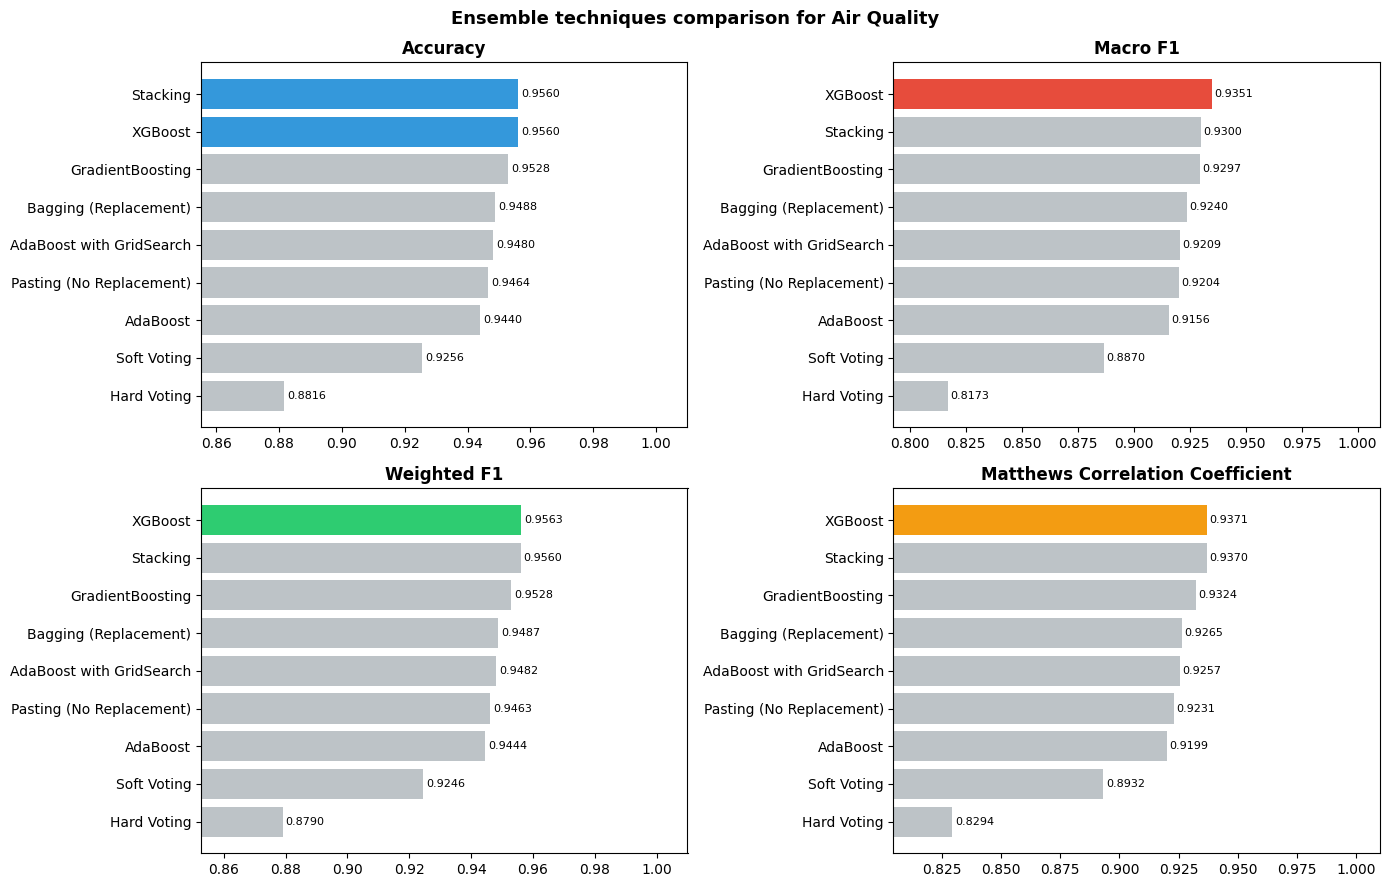

In [171]:
# All metrics' comparison
metrics_cols = ["Accuracy", "Macro F1", "Weighted F1", "Matthews Correlation Coefficient"]
colors       = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for ax, col, color in zip(axes, metrics_cols, colors):
    df_sorted = results_df.sort_values(col, ascending=True)
    bar_colors = [color if v == df_sorted[col].max() else "#bdc3c7" for v in df_sorted[col]]
    bars = ax.barh(df_sorted["Technique"], df_sorted[col], color=bar_colors)
    ax.set_title(col, fontweight="bold")
    ax.set_xlim(df_sorted[col].min() * 0.97, 1.01)
    for bar, val in zip(bars, df_sorted[col]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

fig.suptitle("Ensemble techniques comparison for Air Quality", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Best model for Macro F1: XGBoost

              precision    recall  f1-score   support

   Hazardous       0.91      0.87      0.89       132
        Poor       0.86      0.91      0.89       229
    Moderate       0.98      0.95      0.96       381
        Good       1.00      1.00      1.00       508

    accuracy                           0.96      1250
   macro avg       0.94      0.93      0.94      1250
weighted avg       0.96      0.96      0.96      1250



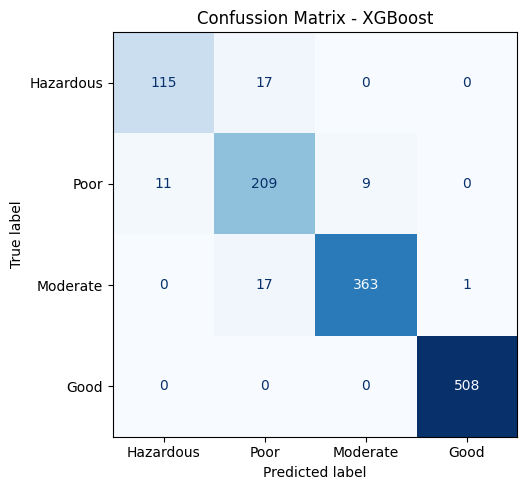

In [172]:
best_name   = results_df.iloc[0]["Technique"]
uses_scaled = best_name in ["Hard Voting", "Soft Voting", "Stacking"]
X_eval      = X_test

model_map = {
    "Hard Voting":              hard_voting_clf,
    "Soft Voting":              soft_voting_clf,
    "Bagging (Replacement)":    bag_clf,
    "Pasting (No Replacement)": past_clf,
    "AdaBoost":                 ada_clf,
    "AdaBoost with GridSearch": ada_grid_clf.best_estimator_,
    "GradientBoosting":         gb_clf,
    "XGBoost":                  xgb_clf,
    "Stacking":                 stacking_clf}

best_model = model_map[best_name]
y_pred     = best_model.predict(X_eval)

print(f"Best model for Macro F1: {best_name}\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

# Confussion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=CLASS_NAMES,
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title(f"Confussion Matrix - {best_name}")
plt.tight_layout()
plt.show()

Recall for 'Hazardous' class (how many dangerous cases each model detects):
XGBoost                     0.871212
Bagging (Replacement)       0.848485
Pasting (No Replacement)    0.848485
GradientBoosting            0.840909
AdaBoost                    0.833333
Stacking                    0.825758
AdaBoost with GridSearch    0.818182
Soft Voting                 0.712121
Hard Voting                 0.606061


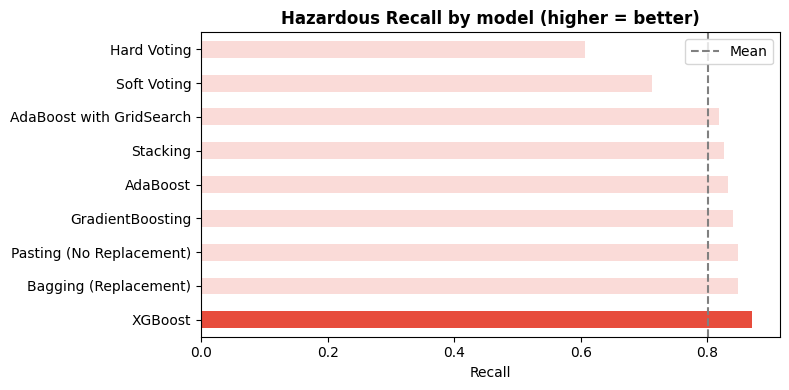

In [173]:
# Recall for the Hazardous class for all models

from sklearn.metrics import recall_score

hazardous_recall = {}
for row in all_metrics:
    name  = row["Technique"]
    model = model_map[name]
    yp    = model.predict(X_test)
    recalls = recall_score(y_test, yp, average=None, labels=[0, 1, 2, 3])
    hazardous_recall[name] = recalls[0]   # index 0 is Hazardous

haz_df = pd.Series(hazardous_recall).sort_values(ascending=False)
print("Recall for 'Hazardous' class (how many dangerous cases each model detects):")
print(haz_df.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["#e74c3c" if v == haz_df.max() else "#fadbd8" for v in haz_df.values]
haz_df.plot(kind="barh", ax=ax, color=bar_colors)
ax.set_title("Hazardous Recall by model (higher = better)", fontweight="bold")
ax.set_xlabel("Recall")
ax.axvline(x=haz_df.mean(), linestyle="--", color="gray", label="Mean")
ax.legend()
plt.tight_layout()
plt.show()

`The ensemble learning methods significantly improve predictive performance compared to individual models.` Over all evaluated metrics (accuracy, macro F1-score, and Matthews Correlation Coefficient (MCC)), ensemble approaches consistently get the best scores, suggesting that they generalize better and get less errors.

Comparing different `aggregation strategies`, `soft voting is better than hard voting`, as it incorporates class probabilities and better captures model confidence. This leads to more reliable predictions, particularly when combining models of varying strengths.

The `bagging` strategy seems to achieve `good performance with low overfitting.` Its Out-of-Bag (OOB) score secures its performance without additional validation data. However, `it's weaker in detecting the “Hazardous” category.`

In the `boosting` case, it gets a `better performance over bagging`. Techniques like early stopping help preventing overfitting while maintaining precise generalization.

`The best results are obtained with Extreme Gradient Boosting (XGBoost)`, which achieves the highest scores across all evaluation metrics. It provides the best balance between accuracy and performance, making it `the most reliable model in this analysis.`

The `stacking approach`, despite its higher complexity, `doesn't work better than XGBoost`. This indicates that additional model combination layers do not necessarily lead to better performance. Maybe we could define a stack of blenders to see if it works better.

A key challenge we work on this project is the class imbalance, particularly in `the detection of the “Hazardous” class`. All models have lower recall for this category, `highlighting the need for further techniques such as cost sensitive learning` if we want to deploy it in a real case.

In summary, while bagging offers robustness and stability, `boosting methods and especially XGBoost have a great predictive performance`. Therefore, `we select XGBoost as the final model for this task` and we will save it.

In [174]:
import joblib

# Save the best model
joblib.dump(best_model, "../src/models/ensemble_model.pkl")

['../src/models/ensemble_model.pkl']